# 📊 EDA Dashboard: Global Sales Analysis
**Project #1** | Skills: Pandas, Matplotlib, Seaborn, Plotly, Statistical Analysis, Data Storytelling

---

##  What this project covers:
-  Comprehensive Exploratory Data Analysis (EDA)
-  Statistical summaries & outlier detection
-  Interactive Plotly visualizations
-  Correlation analysis
-  Business insight generation
-  Professional dashboard layout

---

##  Project Structure
| Step | Description |
|------|-------------|
| 1 | Install & Import Libraries |
| 2 | Generate Realistic Sales Dataset |
| 3 | Statistical Summary & Outlier Detection |
| 4 | Revenue Analysis Dashboard (Matplotlib + Seaborn) |
| 5 | Interactive Plotly Charts |
| 6 | Key Business Insights |

---
##  Step 1: Install & Import Libraries
We begin by installing all required libraries and importing them.
Each library serves a specific purpose in our analysis pipeline.

In [7]:
# Install all required libraries in one command
# The -q flag suppresses verbose output to keep the notebook clean
# pandas      → data manipulation and analysis
# numpy       → numerical computing and array operations
# matplotlib  → base plotting library for static charts
# seaborn     → statistical visualization built on top of matplotlib
# plotly      → interactive charts (hover, zoom, pan)
# scipy       → statistical functions (used for correlation, distributions)
!pip install pandas numpy matplotlib seaborn plotly scipy -q

In [8]:
# ── Core data libraries ──────────────────────────────────────────────────────
import pandas as pd          # DataFrame operations: groupby, merge, pivot, etc.
import numpy as np           # Array math, random number generation, statistics

# ── Static visualization libraries ───────────────────────────────────────────
import matplotlib.pyplot as plt              # Main plotting engine
import matplotlib.gridspec as gridspec       # Advanced multi-panel grid layouts
import seaborn as sns                        # Heatmaps, distribution plots, palettes

# ── Interactive visualization library ────────────────────────────────────────
import plotly.express as px                  # High-level Plotly API (quick charts)
import plotly.graph_objects as go            # Low-level Plotly API (custom charts)
from plotly.subplots import make_subplots   # Multi-panel interactive layouts

# ── Statistical computing ─────────────────────────────────────────────────────
from scipy import stats      # Pearson correlation, normality tests, distributions

# ── Suppress non-critical warnings for cleaner output ────────────────────────
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Step 2: Generate Realistic Sales Dataset

We synthetically generate 2,000 sales transactions covering Jan 2022 – Dec 2023.

**Why synthetic data?**
- Fully reproducible (fixed random seed)
- We control the statistical properties (seasonality, noise, multipliers)
- No privacy or licensing concerns

**Revenue formula:**
> `revenue = base_price × region_multiplier × seasonality × noise`

In [9]:
# ── Reproducibility ───────────────────────────────────────────────────────────
# Setting a fixed seed ensures that every time this notebook is run,
# the exact same random numbers are generated → same dataset → same results.
# This is critical for reproducible research and portfolio projects.
np.random.seed(42)

# ── Dataset size ──────────────────────────────────────────────────────────────
# n = number of transactions (rows) in our dataset
n = 2000

# ── Define categorical dimensions ─────────────────────────────────────────────
# These are the possible values for each categorical column.
# In a real dataset these would come from your CRM / ERP system.
regions    = ['North America', 'Europe', 'Asia Pacific', 'Latin America', 'Middle East']
categories = ['Electronics', 'Clothing', 'Food & Beverage', 'Home & Garden', 'Sports']
channels   = ['Online', 'Retail Store', 'Wholesale', 'Direct Sales']

print(f'Regions   : {regions}')
print(f'Categories: {categories}')
print(f'Channels  : {channels}')
print(f'Total rows: {n}')

Regions   : ['North America', 'Europe', 'Asia Pacific', 'Latin America', 'Middle East']
Categories: ['Electronics', 'Clothing', 'Food & Beverage', 'Home & Garden', 'Sports']
Channels  : ['Online', 'Retail Store', 'Wholesale', 'Direct Sales']
Total rows: 2000


In [10]:
# ── Base revenue by product category ──────────────────────────────────────────
# This represents the average transaction value floor for each category.
# Electronics is highest because individual items cost more.
# Food & Beverage is lowest because it's high-frequency, low-ticket.
cat_base = {
    'Electronics':    800,   # High-value items (laptops, phones, TVs)
    'Clothing':       200,   # Mid-range apparel
    'Food & Beverage':150,   # Low-ticket, high-volume
    'Home & Garden':  350,   # Medium-value household goods
    'Sports':         280    # Sports equipment and gear
}

# ── Regional revenue multipliers ──────────────────────────────────────────────
# Wealthier / larger markets have higher purchasing power → higher revenue per transaction.
# North America is the biggest and most affluent market (1.4× multiplier).
# Latin America and Middle East are emerging markets with lower spend per transaction.
reg_mult = {
    'North America': 1.4,   # Largest, most affluent market
    'Europe':        1.2,   # Strong purchasing power
    'Asia Pacific':  1.1,   # Large market, growing but mixed incomes
    'Latin America': 0.8,   # Emerging market, lower spend per transaction
    'Middle East':   0.9    # Smaller market, conservative spend
}

print('Base revenues per category (USD):')
for k, v in cat_base.items():
    print(f'  {k:<20} ${v}')

print('\nRegional revenue multipliers:')
for k, v in reg_mult.items():
    print(f'  {k:<20} ×{v}')

Base revenues per category (USD):
  Electronics          $800
  Clothing             $200
  Food & Beverage      $150
  Home & Garden        $350
  Sports               $280

Regional revenue multipliers:
  North America        ×1.4
  Europe               ×1.2
  Asia Pacific         ×1.1
  Latin America        ×0.8
  Middle East          ×0.9


In [11]:
# ── Generate date range ───────────────────────────────────────────────────────
# pd.date_range creates n evenly spaced timestamps between two dates.
# This simulates transactions spread uniformly across 2 years.
dates = pd.date_range('2022-01-01', '2023-12-31', periods=n)

# ── Randomly assign categorical values to each transaction ────────────────────
# np.random.choice samples randomly from the list, with equal probability for each option.
# The result is a numpy array of length n.
category = np.random.choice(categories, n)   # e.g. ['Electronics', 'Clothing', ...]
region   = np.random.choice(regions, n)      # e.g. ['Europe', 'North America', ...]
channel  = np.random.choice(channels, n)     # e.g. ['Online', 'Wholesale', ...]

print(f'Dates range: {dates[0].date()} → {dates[-1].date()}')
print(f'\nSample categories : {category[:5]}')
print(f'Sample regions    : {region[:5]}')
print(f'Sample channels   : {channel[:5]}')

Dates range: 2022-01-01 → 2023-12-31

Sample categories : ['Home & Garden' 'Sports' 'Food & Beverage' 'Sports' 'Sports']
Sample regions    : ['Latin America' 'Asia Pacific' 'Europe' 'North America' 'Middle East']
Sample channels   : ['Direct Sales' 'Wholesale' 'Online' 'Retail Store' 'Online']


In [38]:
# ── Step 1: Look up base revenue for each transaction's category ───────────────
# List comprehension maps each category string to its base revenue value.
# np.array() converts it to a numpy array so we can do vectorized math.
base_revenue = np.array([cat_base[c] for c in category])

# ── Step 2: Look up regional multiplier for each transaction's region ──────────
# Same approach — maps region string to its multiplier float.
reg_factor = np.array([reg_mult[r] for r in region])

# ── Step 3: Apply seasonality ──────────────────────────────────────────────────
# Sales tend to peak mid-year (summer) and dip in winter.
# We model this with a sine wave:
#   - np.sin oscillates between -1 and +1
#   - Multiplying by 0.3 gives a ±30% swing
#   - Adding 1 shifts the range to 0.7 → 1.3 (always positive)
# Result: revenue is 30% higher at peak months, 30% lower at off-peak months.
seasonality = 1 + 0.3 * np.sin(2 * np.pi * pd.to_datetime(dates).month.values / 12)

# ── Step 4: Add random noise using log-normal distribution ───────────────────
# Real sales data is never perfectly smooth — individual transactions vary.
# Log-normal noise is ideal here because:
#   - It is always positive (you can't have negative revenue multiplier)
#   - It produces realistic right-skewed variation
#   - mean=0, std=0.3 gives moderate transaction-level randomness
noise = np.random.lognormal(0, 0.3, n)

# ── Step 5: Combine all factors into final revenue ────────────────────────────
# Revenue = base × region_factor × seasonal_factor × random_noise
# All four arrays have length n, so element-wise multiplication works.
revenue = base_revenue * reg_factor * seasonality * noise

print('Revenue statistics (before rounding):')
print(f'  Min    : ${revenue.min():.2f}')
print(f'  Max    : ${revenue.max():.2f}')
print(f'  Mean   : ${revenue.mean():.2f}')
print(f'  Median : ${np.median(revenue):.2f}')

Revenue statistics (before rounding):
  Min    : $50.94
  Max    : $3817.37
  Mean   : $410.76
  Median : $288.42


In [39]:
# ── Units sold ────────────────────────────────────────────────────────────────
# Units sold is proportional to revenue relative to the base price,
# scaled by a random integer (1–19) to add variation.
# np.array() is CRITICAL here — without it, the division can return a
# pandas Index object which doesn't support .clip(), causing AttributeError.
# .astype(int)  → converts float result to integer (no fractional units)
# .clip(1)      → ensures minimum of 1 unit (no zero or negative units)
units = (
    np.array(revenue) / np.array(base_revenue)
    * np.random.randint(1, 20, n)
).astype(int).clip(1)

# ── Discount percentage ───────────────────────────────────────────────────────
# Most transactions have no discount (40% probability).
# The probability decreases as discount size increases — realistic for retail.
# p=[0.4, 0.2, 0.2, 0.1, 0.06, 0.04] are the probabilities for each tier.
discount_pct = np.random.choice(
    [0, 5, 10, 15, 20, 25], n,
    p=[0.4, 0.2, 0.2, 0.1, 0.06, 0.04]   # must sum to 1.0
)

# ── Profit margin ─────────────────────────────────────────────────────────────
# Base margin is randomly drawn between 10% and 45%.
# Each 1% of discount reduces the margin by 0.5 percentage points.
# This captures the real-world effect: higher discounts compress profitability.
# Formula: margin = random_base_margin - (discount_pct × 0.005)
profit_margin = np.random.uniform(0.10, 0.45, n) - discount_pct * 0.005

print('Units sold  — min:', units.min(), '| max:', units.max())
print('Discount %  — unique values:', sorted(set(discount_pct)))
print('Profit margin — min:', profit_margin.min().round(4), '| max:', profit_margin.max().round(4))

Units sold  — min: 1 | max: 70
Discount %  — unique values: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25)]
Profit margin — min: -0.0081 | max: 0.4491


In [40]:
# ── Assemble the DataFrame ────────────────────────────────────────────────────
# pd.DataFrame() takes a dictionary where:
#   - keys   → column names
#   - values → arrays of length n (one value per row)
# .round(2) keeps revenue/margin to 2 decimal places (cents precision)
df = pd.DataFrame({
    'date':                 dates,                        # Timestamp of transaction
    'region':               region,                       # Geographic region
    'category':             category,                     # Product category
    'channel':              channel,                      # Sales channel
    'revenue':              revenue.round(2),             # Transaction revenue in USD
    'units_sold':           units,                        # Number of units purchased
    'discount_pct':         discount_pct,                 # Discount applied (%)
    'profit_margin':        profit_margin.round(4),       # Net profit margin (0–1 scale)
    'customer_age':         np.random.randint(18, 70, n), # Customer age (18–69)
    'customer_satisfaction':np.random.choice(            # Satisfaction score (1–5)
        [1, 2, 3, 4, 5], n,
        p=[0.05, 0.10, 0.20, 0.35, 0.30]  # Skewed positive: most customers are satisfied
    )
})

# ── Derived columns ───────────────────────────────────────────────────────────
# profit = revenue × margin  (e.g. $500 revenue at 25% margin = $125 profit)
df['profit']  = (df['revenue'] * df['profit_margin']).round(2)

# Extract date components for time-based grouping
df['month']   = df['date'].dt.month    # 1–12
df['quarter'] = df['date'].dt.quarter  # 1–4
df['year']    = df['date'].dt.year     # 2022 or 2023

# ── Verify the result ─────────────────────────────────────────────────────────
print('Dataset shape:', df.shape)   # Should be (2000, 14)
print(f'Date range: {df.date.min().date()} → {df.date.max().date()}')
print(f'Columns: {list(df.columns)}')
df.head()   # Display first 5 rows as a table

Dataset shape: (2000, 14)
Date range: 2022-01-01 → 2023-12-31
Columns: ['date', 'region', 'category', 'channel', 'revenue', 'units_sold', 'discount_pct', 'profit_margin', 'customer_age', 'customer_satisfaction', 'profit', 'month', 'quarter', 'year']


,date,region,category,channel,revenue,units_sold,discount_pct,profit_margin,customer_age,customer_satisfaction,profit,month,quarter,year
0,2022-01-01 00:00:00.000000000,Latin America,Home & Garden,Direct Sales,424.97,4,0,0.2229,40,4,94.73,1,1,2022
1,2022-01-01 08:45:08.554277138,Asia Pacific,Sports,Wholesale,519.60,27,5,0.2946,28,3,153.07,1,1,2022
2,2022-01-01 17:30:17.108554277,Europe,Food & Beverage,Online,208.89,18,5,0.1380,25,5,28.83,1,1,2022
3,2022-01-02 02:15:25.662831415,North America,Sports,Retail Store,505.55,32,5,0.1447,25,5,73.15,1,1,2022
4,2022-01-02 11:00:34.217108554,Middle East,Sports,Online,164.39,2,0,0.4237,54,4,69.65,1,1,2022


---
## Step 3: Statistical Summary & Data Quality

Before visualising or modelling, we must understand the data's:
- **Shape** — dimensions and data types
- **Distribution** — central tendency and spread
- **Completeness** — missing values
- **Outliers** — extreme values that could distort analysis

In [41]:
# ── Data types and memory usage ───────────────────────────────────────────────
# df.info() shows:
#   - Column names
#   - Non-null count (useful for spotting missing data)
#   - Data type of each column (object, float64, int64, datetime64)
#   - Total memory usage of the DataFrame
# This is always the FIRST thing to run on a new dataset.
print('=== DATA TYPES & MEMORY ===')
df.info()

=== DATA TYPES & MEMORY ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   2000 non-null   datetime64[ns]
 1   region                 2000 non-null   object        
 2   category               2000 non-null   object        
 3   channel                2000 non-null   object        
 4   revenue                2000 non-null   float64       
 5   units_sold             2000 non-null   int64         
 6   discount_pct           2000 non-null   int64         
 7   profit_margin          2000 non-null   float64       
 8   customer_age           2000 non-null   int32         
 9   customer_satisfaction  2000 non-null   int64         
 10  profit                 2000 non-null   float64       
 11  month                  2000 non-null   int32         
 12  quarter                2000 non-nu

In [42]:
# ── Statistical summary ───────────────────────────────────────────────────────
# df.describe() computes 8 statistics for every numeric column:
#   count  → number of non-null values (confirms no missing data)
#   mean   → arithmetic average
#   std    → standard deviation (spread around the mean)
#   min    → smallest value
#   25%    → first quartile (Q1): 25% of values fall below this
#   50%    → median (Q2): middle value
#   75%    → third quartile (Q3): 75% of values fall below this
#   max    → largest value
# We select only the 4 most analytically important columns.
# .round(2) keeps the output readable.
print('=== STATISTICAL SUMMARY ===')
df[['revenue', 'units_sold', 'profit_margin', 'customer_satisfaction']].describe().round(2)

=== STATISTICAL SUMMARY ===


,revenue,units_sold,profit_margin,customer_satisfaction
count,2000.00,2000.00,2000.00,2000.00
mean,410.76,10.82,0.24,3.74
std,352.27,8.22,0.11,1.12
min,50.94,1.00,-0.01,1.00
25%,186.61,4.00,0.15,3.00
50%,288.42,9.00,0.24,4.00
75%,509.60,15.00,0.33,5.00
max,3817.37,70.00,0.45,5.00


In [43]:
# ── Missing value check ───────────────────────────────────────────────────────
# df.isnull() returns a boolean DataFrame (True where value is NaN).
# .sum() counts the True values per column.
# In a synthetic dataset we expect 0 missing values everywhere.
# In a real dataset, this step often reveals data quality issues:
#   - Incomplete CRM entries
#   - Failed API responses
#   - Optional fields left blank
print('=== MISSING VALUES PER COLUMN ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')
print('✅ No missing values — dataset is complete.' if missing.sum() == 0 else '⚠️ Missing values detected!')

=== MISSING VALUES PER COLUMN ===
date                     0
region                   0
category                 0
channel                  0
revenue                  0
units_sold               0
discount_pct             0
profit_margin            0
customer_age             0
customer_satisfaction    0
profit                   0
month                    0
quarter                  0
year                     0
dtype: int64

Total missing values: 0
✅ No missing values — dataset is complete.


In [44]:
# ── Outlier detection using the IQR method ────────────────────────────────────
# The Interquartile Range (IQR) method is the standard non-parametric approach
# for detecting outliers. It does NOT assume a normal distribution.
#
# HOW IT WORKS:
#   Q1 = 25th percentile (lower quartile)
#   Q3 = 75th percentile (upper quartile)
#   IQR = Q3 - Q1  (the middle 50% of the data)
#
#   A value is an outlier if:
#     value < Q1 - 1.5 × IQR   (extreme low)
#     value > Q3 + 1.5 × IQR   (extreme high)
#
#   The 1.5 multiplier is the standard Tukey fence — it catches ~0.7% of
#   a normal distribution as outliers, which is the accepted threshold.

print('=== OUTLIER DETECTION (IQR Method) ===')
print(f'{"Column":<15} {"Q1":>8} {"Q3":>8} {"IQR":>8} {"Lower fence":>12} {"Upper fence":>12} {"Outliers":>10} {"Pct":>6}')
print('-' * 85)

for col in ['revenue', 'profit']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])   # Compute quartiles
    IQR    = Q3 - Q1                            # Interquartile range
    lower  = Q1 - 1.5 * IQR                    # Lower fence
    upper  = Q3 + 1.5 * IQR                    # Upper fence

    # Boolean mask: True where value is outside the fences
    outlier_mask = (df[col] < lower) | (df[col] > upper)
    n_outliers   = outlier_mask.sum()
    pct          = n_outliers / len(df) * 100

    print(f'{col:<15} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} {lower:>12.1f} {upper:>12.1f} {n_outliers:>10} {pct:>5.1f}%')

print('\n💡 Note: These outliers come from the log-normal noise. In a real project,')
print('   investigate each outlier — do not automatically remove them.')

=== OUTLIER DETECTION (IQR Method) ===
Column                Q1       Q3      IQR  Lower fence  Upper fence   Outliers    Pct
-------------------------------------------------------------------------------------
revenue            186.6    509.6    323.0       -297.9        994.1        155   7.8%
profit              35.1    122.2     87.0        -95.4        252.7        162   8.1%

💡 Note: These outliers come from the log-normal noise. In a real project,
   investigate each outlier — do not automatically remove them.


In [45]:
# ── Category-level summary ────────────────────────────────────────────────────
# groupby('category') splits the DataFrame into 5 groups (one per category).
# .agg() applies multiple aggregation functions at once:
#   sum    → total revenue for the category
#   mean   → average transaction value
#   count  → number of transactions
# .sort_values() sorts by total revenue descending (highest first).
# .round(2) keeps output tidy.
print('=== REVENUE SUMMARY BY CATEGORY ===')
cat_summary = df.groupby('category').agg(
    total_revenue  = ('revenue', 'sum'),
    avg_order_value= ('revenue', 'mean'),
    transactions   = ('revenue', 'count'),
    avg_margin     = ('profit_margin', 'mean')
).round(2).sort_values('total_revenue', ascending=False)

print(cat_summary)

=== REVENUE SUMMARY BY CATEGORY ===
                 total_revenue  avg_order_value  transactions  avg_margin
category                                                                 
Electronics          384917.51           927.51           415        0.25
Home & Garden        157789.24           398.46           396        0.24
Sports               125957.16           307.96           409        0.24
Clothing              89637.32           223.53           401        0.24
Food & Beverage       63215.70           166.80           379        0.24


---
## Step 4: Revenue Analysis Dashboard (Matplotlib + Seaborn)

We build a 3×3 multi-panel static dashboard using `GridSpec`.
Each panel answers a specific business question.

| Panel | Question Answered |
|-------|------------------|
| 1 | Which category earns most? |
| 2 | What is each region's revenue share? |
| 3 | Is there seasonal trend in monthly revenue? |
| 4 | Which channel is most profitable? |
| 5 | What does the revenue distribution look like? |
| 6 | How do numeric variables correlate? |
| 7 | Do satisfied customers spend more? |
| 8 | How do discounts affect profit margins? |
| 9 | How does revenue compare across quarters? |

In [46]:
# ── Dashboard canvas setup ────────────────────────────────────────────────────
# figsize=(18, 12) → wide canvas (18 inches × 12 inches) for 9 panels
fig = plt.figure(figsize=(18, 12))

# GridSpec divides the figure into a 3-row × 3-column grid.
# hspace = vertical space between rows (0.4 = 40% of average subplot height)
# wspace = horizontal space between columns
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# Main title for the entire dashboard
fig.suptitle('Global Sales EDA Dashboard', fontsize=20, fontweight='bold', y=0.98)

# Color palette: 'husl' produces 5 evenly spaced, visually distinct colors
palette = sns.color_palette('husl', 5)

print('Dashboard canvas ready — 3×3 grid with 9 panels')

Dashboard canvas ready — 3×3 grid with 9 panels


<Figure size 1800x1200 with 0 Axes>

In [47]:
# ── Panel 1 (row 0, col 0): Revenue by Category ───────────────────────────────
# WHAT: Horizontal bar chart showing total revenue per product category
# WHY:  Quickly identifies which product lines drive the most sales volume
# HOW:
#   groupby('category')  → split into 5 groups
#   ['revenue'].sum()    → total revenue per group
#   .sort_values(ascending=True) → shortest bar at top, longest at bottom
#                                  (natural reading order for horizontal bars)
#   / 1e6                → convert dollars to millions for readable axis labels

ax1 = fig.add_subplot(gs[0, 0])   # Position: row 0, column 0

cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=True)
ax1.barh(cat_rev.index, cat_rev.values / 1e6, color=palette)

ax1.set_title('Revenue by Category ($M)', fontweight='bold')
ax1.set_xlabel('Revenue ($M)')

print('Panel 1 added: Revenue by Category')

Panel 1 added: Revenue by Category


In [48]:
# ── Panel 2 (row 0, col 1): Revenue Share by Region ──────────────────────────
# WHAT: Pie chart showing each region's percentage of total revenue
# WHY:  Pie charts are ideal for showing proportional composition at a glance
# HOW:
#   groupby + sum()          → total revenue per region
#   .sort_values(ascending=False) → largest slice first (12 o'clock position)
#   autopct='%1.1f%%'        → display percentage on each slice (1 decimal)
#   startangle=140           → rotate start for better label placement

ax2 = fig.add_subplot(gs[0, 1])   # Position: row 0, column 1

reg_rev = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
ax2.pie(
    reg_rev.values,
    labels=reg_rev.index,
    autopct='%1.1f%%',
    colors=palette,
    startangle=140
)
ax2.set_title('Revenue Share by Region', fontweight='bold')

print('Panel 2 added: Revenue Share by Region')

Panel 2 added: Revenue Share by Region


In [49]:
# ── Panel 3 (row 0, col 2): Monthly Revenue Trend ────────────────────────────
# WHAT: Line chart showing revenue per month, with separate lines for 2022 & 2023
# WHY:  Reveals seasonality patterns and allows year-over-year comparison
# HOW:
#   groupby(['year','month'])  → group by both year and month simultaneously
#   .reset_index()             → flatten the MultiIndex back to regular columns
#   Loop by year               → plot one line per year so we can compare them
#   / 1e3                      → scale to thousands for readable y-axis

ax3 = fig.add_subplot(gs[0, 2])   # Position: row 0, column 2

monthly = df.groupby(['year', 'month'])['revenue'].sum().reset_index()

for yr in monthly['year'].unique():
    m = monthly[monthly['year'] == yr]    # Filter rows for this year
    ax3.plot(
        m['month'], m['revenue'] / 1e3,
        marker='o',       # Dot at each data point
        label=str(yr),    # Legend label
        linewidth=2
    )

ax3.set_title('Monthly Revenue Trend ($K)', fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Revenue ($K)')
ax3.legend()

print('Panel 3 added: Monthly Revenue Trend')

Panel 3 added: Monthly Revenue Trend


In [50]:
# ── Panel 4 (row 1, col 0): Channel Revenue vs Profit ────────────────────────
# WHAT: Grouped bar chart comparing total revenue AND profit per sales channel
# WHY:  A channel can generate high revenue but low profit (e.g. due to discounts).
#       Showing both metrics side-by-side reveals channel efficiency.
# HOW:
#   .agg() with multiple functions  → compute both revenue and profit in one step
#   np.arange()                     → evenly spaced x positions for bar groups
#   x - 0.2 / x + 0.2              → offset each bar by 0.2 to place them side-by-side
#   bar width = 0.4                 → total grouped width = 0.8 (leaves 0.2 gap)

ax4 = fig.add_subplot(gs[1, 0])   # Position: row 1, column 0

ch_stats = df.groupby('channel').agg(
    revenue=('revenue', 'sum'),
    profit =('profit',  'sum')
).reset_index()

x = np.arange(len(ch_stats))   # [0, 1, 2, 3] for 4 channels

ax4.bar(x - 0.2, ch_stats['revenue'] / 1e6, 0.4, label='Revenue', color='#3498db')
ax4.bar(x + 0.2, ch_stats['profit']  / 1e6, 0.4, label='Profit',  color='#2ecc71')

ax4.set_xticks(x)
ax4.set_xticklabels(ch_stats['channel'], rotation=15, fontsize=8)
ax4.set_title('Channel: Revenue vs Profit ($M)', fontweight='bold')
ax4.set_ylabel('Amount ($M)')
ax4.legend(fontsize=8)

print('Panel 4 added: Channel Revenue vs Profit')

Panel 4 added: Channel Revenue vs Profit


In [51]:
# ── Panel 5 (row 1, col 1): Revenue Distribution ─────────────────────────────
# WHAT: Histogram of transaction revenue values with mean and median overlaid
# WHY:  Understanding the distribution shape is fundamental to EDA:
#         - Is it normal (bell-shaped)?
#         - Is it right-skewed (long tail on the right — common in sales data)?
#         - Are there multiple peaks (bimodal) suggesting different customer segments?
# HOW:
#   bins=50          → 50 histogram bars (enough detail without being noisy)
#   alpha=0.7        → slight transparency so bars look cleaner
#   axvline()        → vertical reference lines showing mean and median
#   If mean > median → right skew (a few very large transactions pull the mean up)

ax5 = fig.add_subplot(gs[1, 1])   # Position: row 1, column 1

ax5.hist(df['revenue'], bins=50, color='#9b59b6', alpha=0.7, edgecolor='white')

# Add mean line (red dashed) — pulled right by outliers
ax5.axvline(
    df['revenue'].mean(), color='red', linestyle='--',
    label=f'Mean: ${df["revenue"].mean():.0f}'
)
# Add median line (orange dashed) — resistant to outliers, better "typical" value
ax5.axvline(
    df['revenue'].median(), color='orange', linestyle='--',
    label=f'Median: ${df["revenue"].median():.0f}'
)

ax5.set_title('Revenue Distribution', fontweight='bold')
ax5.set_xlabel('Revenue ($)')
ax5.set_ylabel('Frequency')
ax5.legend(fontsize=8)

print('Panel 5 added: Revenue Distribution')

Panel 5 added: Revenue Distribution


In [52]:
# ── Panel 6 (row 1, col 2): Correlation Heatmap ──────────────────────────────
# WHAT: Triangular heatmap showing Pearson correlation between numeric variables
# WHY:  Correlation analysis helps identify:
#         - Redundant features (highly correlated → consider removing one)
#         - Relationships to explore (e.g. does discount hurt margin?)
#         - Potential confounders in modelling
# HOW:
#   .corr()          → computes the full N×N Pearson correlation matrix
#   np.triu(mask)    → mask the upper triangle to avoid redundant display
#                      (correlation matrix is symmetric, so lower triangle is enough)
#   cmap='RdBu_r'    → Red = negative correlation, Blue = positive correlation
#   center=0         → white = no correlation
#   annot=True       → print correlation values inside each cell

ax6 = fig.add_subplot(gs[1, 2])   # Position: row 1, column 2

corr_cols = ['revenue', 'units_sold', 'discount_pct', 'profit_margin',
             'customer_age', 'customer_satisfaction', 'profit']

corr = df[corr_cols].corr()

# Upper triangle mask (True = masked/hidden)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, ax=ax6, mask=mask,
    annot=True, fmt='.2f',        # Annotate cells with 2-decimal correlations
    cmap='RdBu_r', center=0,
    square=True,                  # Make cells square for readability
    linewidths=0.5,               # Thin grid lines between cells
    annot_kws={'size': 7}         # Small font inside cells to fit them
)
ax6.set_title('Correlation Matrix', fontweight='bold')
ax6.tick_params(axis='x', rotation=45, labelsize=7)
ax6.tick_params(axis='y', rotation=0,  labelsize=7)

print('Panel 6 added: Correlation Heatmap')

Panel 6 added: Correlation Heatmap


In [53]:
# ── Panel 7 (row 2, col 0): Avg Revenue by Customer Satisfaction ──────────────
# WHAT: Bar chart of average transaction revenue grouped by satisfaction score (1–5)
# WHY:  Tests whether happier customers spend more.
#         - If bars increase monotonically → positive relationship
#         - If no pattern → satisfaction and spend are independent
# HOW:
#   groupby('customer_satisfaction')  → 5 groups (one per score)
#   ['revenue'].mean()                → average revenue per group
#   Color list matches scores 1–5: red → orange → yellow → green → teal

ax7 = fig.add_subplot(gs[2, 0])   # Position: row 2, column 0

sat_rev = df.groupby('customer_satisfaction')['revenue'].mean()

ax7.bar(
    sat_rev.index, sat_rev.values,
    color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#1abc9c']  # Red → Teal
)
ax7.set_title('Avg Revenue by Customer Satisfaction', fontweight='bold')
ax7.set_xlabel('Satisfaction Score (1=Low, 5=High)')
ax7.set_ylabel('Avg Revenue ($)')

print('Panel 7 added: Avg Revenue by Customer Satisfaction')

Panel 7 added: Avg Revenue by Customer Satisfaction


In [54]:
# ── Panel 8 (row 2, col 1): Discount % vs Profit Margin ──────────────────────
# WHAT: Line chart showing how average profit margin changes as discount increases
# WHY:  Quantifies the cost of discounting — a key business question.
#       A steep downward slope means even small discounts significantly hurt margins.
# HOW:
#   groupby('discount_pct')    → group by discount tier (0, 5, 10, 15, 20, 25)
#   ['profit_margin'].mean()   → average margin for transactions at that discount level
#   * 100                      → convert 0.25 → 25% for human-readable axis
#   'ro-'                      → red circles connected by a line

ax8 = fig.add_subplot(gs[2, 1])   # Position: row 2, column 1

disc_prof = df.groupby('discount_pct')['profit_margin'].mean()

ax8.plot(
    disc_prof.index,          # X axis: discount % (0, 5, 10, 15, 20, 25)
    disc_prof.values * 100,   # Y axis: avg margin as percentage
    'ro-',                    # Red dots connected by line
    linewidth=2,
    markersize=8
)
ax8.set_title('Discount % vs Profit Margin', fontweight='bold')
ax8.set_xlabel('Discount %')
ax8.set_ylabel('Avg Profit Margin %')

print('Panel 8 added: Discount % vs Profit Margin')

Panel 8 added: Discount % vs Profit Margin


In [55]:
# ── Panel 9 (row 2, col 2): Quarterly Revenue ────────────────────────────────
# WHAT: Bar chart of total revenue per quarter across 2022 and 2023 (8 bars total)
# WHY:  Quarterly view is the standard business reporting cadence.
#       Shows both within-year seasonality and year-over-year growth.
# HOW:
#   groupby(['year','quarter'])  → 8 groups: 2022 Q1-Q4 and 2023 Q1-Q4
#   period column                → human-readable label e.g. '2022 Q1'
#   coolwarm palette             → colour gradient from blue (low) to red (high)
#   range(len(qtr))              → integer x positions for each bar

ax9 = fig.add_subplot(gs[2, 2])   # Position: row 2, column 2

qtr = df.groupby(['year', 'quarter'])['revenue'].sum().reset_index()
qtr['period'] = qtr['year'].astype(str) + ' Q' + qtr['quarter'].astype(str)

ax9.bar(
    range(len(qtr)),
    qtr['revenue'] / 1e6,
    color=sns.color_palette('coolwarm', len(qtr))
)
ax9.set_xticks(range(len(qtr)))
ax9.set_xticklabels(qtr['period'], rotation=45, fontsize=7)
ax9.set_title('Quarterly Revenue ($M)', fontweight='bold')
ax9.set_ylabel('Revenue ($M)')

print('Panel 9 added: Quarterly Revenue')

Panel 9 added: Quarterly Revenue


In [56]:
# ── Render and save the dashboard ─────────────────────────────────────────────
# plt.savefig() saves the figure to disk BEFORE plt.show().
# Always save before showing — plt.show() clears the figure in some backends.
#   dpi=150         → 150 dots per inch (crisp for screens, lower file size than 300)
#   bbox_inches='tight' → trims whitespace around the figure edges
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved as eda_dashboard.png')

<Figure size 640x480 with 0 Axes>

✅ Dashboard saved as eda_dashboard.png


---
## Step 5: Interactive Plotly Charts

Static charts are great for reports, but interactive charts let users:
- **Hover** to see exact values and additional fields
- **Zoom** into specific regions of interest
- **Click** legend items to show/hide categories
- **Pan** across time series

We build two interactive charts using Plotly Express.

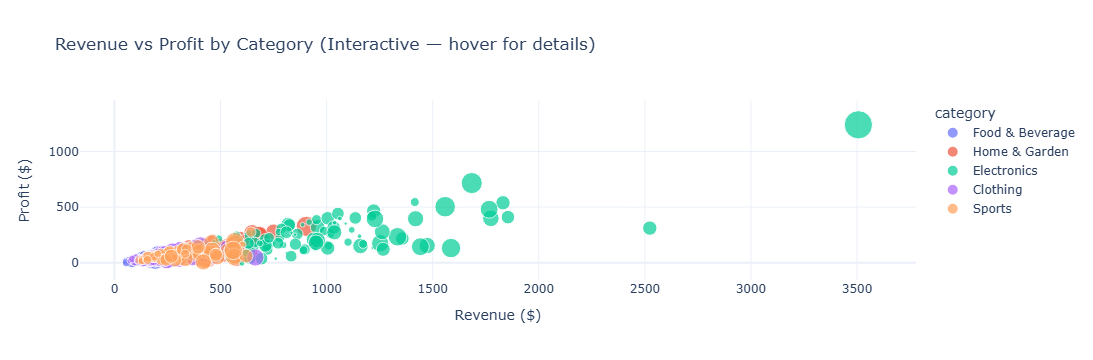

✅ Scatter chart rendered


In [57]:
# ── Interactive Scatter: Revenue vs Profit coloured by Category ───────────────
# WHAT: Each point = one transaction. X = revenue, Y = profit.
# WHY:  Reveals the revenue-profit relationship and whether it differs by category.
# HOW:
#   df.sample(500)       → plot a 500-row random sample (2000 points overlap too much)
#   color='category'     → different colour per product category
#   size='units_sold'    → larger bubble = more units in that transaction
#   hover_data           → extra fields shown in the tooltip on hover
#   template='plotly_white' → clean white background theme

fig_scatter = px.scatter(
    df.sample(500, random_state=42),    # Fixed random_state for reproducibility
    x='revenue',
    y='profit',
    color='category',                   # Colour encode by product category
    size='units_sold',                  # Bubble size encodes units sold
    hover_data=['region', 'channel', 'discount_pct'],  # Tooltip extras
    title='Revenue vs Profit by Category (Interactive — hover for details)',
    labels={'revenue': 'Revenue ($)', 'profit': 'Profit ($)'},
    template='plotly_white'
)
fig_scatter.show()
print('✅ Scatter chart rendered')

In [58]:
# ── Interactive Treemap: Revenue by Region → Category ─────────────────────────
# WHAT: A space-filling hierarchical chart.
#       Outer rectangles = regions. Inner rectangles = categories within each region.
# WHY:  Shows two levels of grouping at once.
#       Rectangle size = proportional to revenue, so larger tiles = more revenue.
#       Colour intensity = revenue magnitude (darker = higher).
# HOW:
#   groupby(['region','category'])  → compute revenue per region-category pair
#   .reset_index()                  → flatten MultiIndex to regular DataFrame
#   path=['region','category']      → defines the 2-level hierarchy
#   values='revenue'                → rectangle size = revenue
#   color_continuous_scale='Viridis'→ purple-green-yellow gradient

treemap_df = df.groupby(['region', 'category'])['revenue'].sum().reset_index()

fig_treemap = px.treemap(
    treemap_df,
    path=['region', 'category'],        # Hierarchy: Region → Category
    values='revenue',                   # Rectangle area = total revenue
    title='Revenue Treemap: Region → Category (click to drill in)',
    color='revenue',
    color_continuous_scale='Viridis'
)
fig_treemap.show()
print('✅ Treemap rendered')

✅ Treemap rendered


---
##  Step 6: Key Business Insights

The final step translates the analysis into concrete business language.
We programmatically compute the top performers and key metrics,
so the insights update automatically if the dataset changes.

In [59]:
# ── Compute top performers ─────────────────────────────────────────────────────
# .groupby().sum()    → total revenue per group
# .idxmax()           → returns the INDEX (label) of the group with the highest value
#                       e.g. if Electronics has highest revenue, idxmax() = 'Electronics'

top_cat    = df.groupby('category')['revenue'].sum().idxmax()          # Top category by revenue
top_reg    = df.groupby('region')['revenue'].sum().idxmax()            # Top region by revenue
top_ch     = df.groupby('channel')['revenue'].sum().idxmax()           # Top channel by revenue
best_marg  = df.groupby('category')['profit_margin'].mean().idxmax()  # Best avg margin category
peak_month = df.groupby('month')['revenue'].sum().idxmax()             # Highest-revenue month (1–12)

# Dictionary to convert month number to abbreviated name
months = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
          7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

print('Top performers computed successfully')
print(f'  Top category : {top_cat}')
print(f'  Top region   : {top_reg}')
print(f'  Top channel  : {top_ch}')
print(f'  Best margin  : {best_marg}')
print(f'  Peak month   : {months[peak_month]}')

Top performers computed successfully
  Top category : Electronics
  Top region   : North America
  Top channel  : Direct Sales
  Best margin  : Electronics
  Peak month   : Mar


In [60]:
# ── Print the KPI summary ──────────────────────────────────────────────────────
# f-strings with format specifiers:
#   :>12    → right-align in a field 12 characters wide (columns line up)
#   ,.0f    → comma thousands separator, zero decimal places
#   ,.2f    → comma thousands separator, 2 decimal places

print('=' * 55)
print('   KEY BUSINESS INSIGHTS FROM EDA')
print('=' * 55)

# ── Overall KPIs ──────────────────────────────────────────────────────────────
print(f'\n💰 Total Revenue:       ${df["revenue"].sum():>12,.0f}')    # Sum of all revenue column
print(f'💵 Total Profit:        ${df["profit"].sum():>12,.0f}')      # Sum of all profit column
print(f'📦 Total Units Sold:    {df["units_sold"].sum():>12,}')      # Total units across all transactions
print(f'📈 Avg Order Value:     ${df["revenue"].mean():>12,.2f}')    # Mean revenue per transaction

# ── Top performers ────────────────────────────────────────────────────────────
print(f'\n🏆 Top Category:        {top_cat}')
print(f'🌍 Top Region:          {top_reg}')
print(f'🛒 Top Channel:         {top_ch}')
print(f'📊 Best Margin Category:{best_marg}')
print(f'📅 Peak Month:          {months[peak_month]}')

# ── Discount-Margin correlation ───────────────────────────────────────────────
# Pearson correlation measures LINEAR relationship between two variables.
# Range: -1 (perfect inverse) to +1 (perfect positive).
# 0 = no linear relationship.
# We expect a NEGATIVE value: more discount → lower margin.
corr_disc = df['discount_pct'].corr(df['profit_margin'])
print(f'\n⚠️  Discount-Margin Correlation: {corr_disc:.3f}')
print(f'   (Negative value confirms: higher discounts compress profit margins)')

   KEY BUSINESS INSIGHTS FROM EDA

💰 Total Revenue:       $     821,517
💵 Total Profit:        $     199,403
📦 Total Units Sold:          21,635
📈 Avg Order Value:     $      410.76

🏆 Top Category:        Electronics
🌍 Top Region:          North America
🛒 Top Channel:         Direct Sales
📊 Best Margin Category:Electronics
📅 Peak Month:          Mar

⚠️  Discount-Margin Correlation: -0.322
   (Negative value confirms: higher discounts compress profit margins)


In [61]:
# ── Detailed revenue & profit breakdown by category ───────────────────────────
# This table gives a complete picture of each category's financial performance.
# profit_rate = profit / revenue × 100  (effective margin as a %)
# revenue_share = category revenue / total revenue × 100

print('\n=== DETAILED CATEGORY BREAKDOWN ===')
total_rev = df['revenue'].sum()

breakdown = df.groupby('category').agg(
    total_revenue  = ('revenue', 'sum'),
    total_profit   = ('profit',  'sum'),
    transactions   = ('revenue', 'count'),
    avg_margin     = ('profit_margin', 'mean')
).round(2)

# Add derived columns
breakdown['revenue_share_%'] = (breakdown['total_revenue'] / total_rev * 100).round(1)
breakdown['avg_order_value'] = (breakdown['total_revenue'] / breakdown['transactions']).round(2)

breakdown = breakdown.sort_values('total_revenue', ascending=False)
print(breakdown.to_string())


=== DETAILED CATEGORY BREAKDOWN ===
                 total_revenue  total_profit  transactions  avg_margin  revenue_share_%  avg_order_value
category                                                                                                
Electronics          384917.51      95031.73           415        0.25             46.9           927.51
Home & Garden        157789.24      37979.21           396        0.24             19.2           398.46
Sports               125957.16      30125.33           409        0.24             15.3           307.96
Clothing              89637.32      21016.34           401        0.24             10.9           223.53
Food & Beverage       63215.70      15250.35           379        0.24              7.7           166.80


In [62]:
# ── Year-over-Year revenue growth ─────────────────────────────────────────────
# Compare total revenue in 2022 vs 2023 to compute YoY growth rate.
# pct_change() computes: (new - old) / old × 100
# This is one of the most important KPIs in any business.

print('\n=== YEAR-OVER-YEAR REVENUE GROWTH ===')
yoy = df.groupby('year')['revenue'].sum()

for yr in yoy.index:
    print(f'  {yr}: ${yoy[yr]:>12,.0f}')

growth = (yoy.iloc[1] - yoy.iloc[0]) / yoy.iloc[0] * 100
direction = '📈' if growth > 0 else '📉'
print(f'\n{direction} YoY Growth: {growth:+.1f}%')


=== YEAR-OVER-YEAR REVENUE GROWTH ===
  2022: $     407,207
  2023: $     414,310

📈 YoY Growth: +1.7%


---
## ✅ Project Summary

| Analysis Step | Technique Used | Library |
|---------------|---------------|----------|
| Data Generation | Multiplicative model with seasonality & noise | NumPy, Pandas |
| Statistical Summary | describe(), info(), null check | Pandas |
| Outlier Detection | IQR method (Tukey fences) | NumPy, Pandas |
| Revenue Analysis | groupby + aggregation | Pandas |
| Trend Analysis | Monthly & quarterly time series | Pandas, Matplotlib |
| Correlation | Pearson heatmap | Seaborn, SciPy |
| Static Dashboard | 3×3 GridSpec multi-panel | Matplotlib, Seaborn |
| Interactive Charts | Scatter plot + Treemap | Plotly Express |
| Business Insights | KPIs, top performers, YoY growth | Pandas |

---
